**Problem Definition:**
The primary objective of this study is to predict cryptocurrency prices (Bitcoin, Ethereum, Solana) based on historical data. Given the volatile nature of the crypto market, accurate forecasting can assist traders and investors in making informed decisions. The study aims to answer: "Can we effectively predict cryptocurrency price movements using historical data and machine learning models?"

**Dataset Description:**
The dataset consists of historical price data for Bitcoin (BTC-USD), Ethereum (ETH-USD), and Solana (SOL-USD) collected from Yahoo Finance. It spans from January 1, 2020, to March 22, 2024, and includes key attributes such as:
- Open price
- High price
- Low price
- Closing price
- Volume

**Methodology:**
1. **Data Collection:** Historical data is retrieved using the `yfinance` library.
2. **Exploratory Data Analysis (EDA):** Trends, volatility, and correlations are visualized using `matplotlib` and `seaborn`.
3. **Data Preprocessing:**
   - Handling missing values
   - Feature scaling using `MinMaxScaler`
   - Creating lag-based features for time series forecasting
4. **Machine Learning Models:**
   - **XGBoost Regressor**: A gradient boosting method used for structured time series prediction.
   - **LSTM (Long Short-Term Memory) Neural Network**: A deep learning approach specifically designed for sequential data.
5. **Model Evaluation:**
   - Root Mean Squared Error (RMSE) is used to assess model accuracy.
   - Train-test split and cross-validation techniques are applied.

**Key Findings:**
- LSTM demonstrated superior performance in capturing long-term trends compared to XGBoost.
- Feature scaling and lagged features significantly improved prediction accuracy.
- Short-term predictions were more reliable than long-term forecasts due to market volatility.

**Conclusions & Recommendations:**
- LSTM is an effective tool for crypto price forecasting, but hyperparameter tuning and larger datasets can enhance accuracy.
- Combining technical indicators (e.g., moving averages, RSI) and external macroeconomic data (e.g., stock indices, market sentiment) could improve predictions.
- Future work should explore hybrid models integrating multiple forecasting techniques.

**Limitations & Future Improvements:**
- The dataset lacks external factors such as economic news, regulatory changes, and market sentiment, which can significantly impact price movements.
- Adding stock indices (e.g., S&P 500, Nasdaq), interest rates, and inflation data could provide a more holistic view.
- Exploring transformer-based models like `TimeSeriesTransformer` may further improve predictions.

In [1]:
import os
import logging
import pandas as pd
import numpy as np

import yfinance as yf

import xgboost as xgb
from xgboost import XGBRegressor

from sklearn.model_selection import KFold, GridSearchCV, train_test_split
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import MinMaxScaler

from keras.models import Sequential
from keras.layers import LSTM, Dense, Input

import matplotlib.pyplot as plt
import seaborn as sns

Get the Data

In [2]:
# Set up logging
logging.basicConfig(format="%(asctime)s - %(levelname)s - %(message)s", level=logging.INFO)
logger = logging.getLogger(__name__)

# Parameters
crypto_symbols = ["BTC-USD", "ETH-USD", "SOL-USD"]  # List of cryptocurrencies
start_date = "2020-01-01"  # Start date
end_date = "2024-03-22"    # End date
data_folder = "data"

# Create a directory if it doesn't exist
os.makedirs(data_folder, exist_ok=True)

# Download data for each cryptocurrency
for symbol in crypto_symbols:
    logger.info(f"Fetching historical data for {symbol} from {start_date} to {end_date}...")
    
    try:
        df = yf.download(symbol, start=start_date, end=end_date, interval="1d")
        df.reset_index(inplace=True)  # Move "Date" from index to a column
        
        # Save to CSV
        file_path = f"{data_folder}/{symbol}_historical.csv"
        df.to_csv(file_path, index=False)
        
        logger.info(f"✅ Data saved to {file_path} ({len(df)} records)")
    
    except Exception as e:
        logger.error(f"Failed to fetch data for {symbol}: {e}")

2025-03-23 13:27:08,136 - INFO - Fetching historical data for BTC-USD from 2020-01-01 to 2024-03-22...


YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed
2025-03-23 13:27:08,707 - INFO - ✅ Data saved to data/BTC-USD_historical.csv (1542 records)
2025-03-23 13:27:08,707 - INFO - Fetching historical data for ETH-USD from 2020-01-01 to 2024-03-22...
[*********************100%***********************]  1 of 1 completed
2025-03-23 13:27:08,836 - INFO - ✅ Data saved to data/ETH-USD_historical.csv (1542 records)
2025-03-23 13:27:08,836 - INFO - Fetching historical data for SOL-USD from 2020-01-01 to 2024-03-22...
[*********************100%***********************]  1 of 1 completed
2025-03-23 13:27:08,986 - INFO - ✅ Data saved to data/SOL-USD_historical.csv (1442 records)


In [3]:
# Initialize combined dataset as None
df_combined = None

# Process each file
for symbol in crypto_symbols:
    file_path = os.path.join(data_folder, f"{symbol}_historical.csv")

    if not os.path.exists(file_path):
        logger.warning(f"⚠️ File not found: {file_path}")
        continue

    logger.info(f"Processing {file_path}")
    
    # Read all lines from the file
    with open(file_path, 'r') as f:
        lines = f.readlines()
    
    # If there are at least 3 lines and the second contains the symbol name
    if len(lines) >= 3 and symbol in lines[1]:
        # Keep only the header and data rows (skip row with symbol names)
        filtered_lines = [lines[0]] + lines[2:]
        
        # Write back to a temporary file
        temp_file = f"{file_path}.temp"
        with open(temp_file, 'w') as f:
            f.writelines(filtered_lines)
            
        # Read the cleaned file
        df = pd.read_csv(temp_file)
        os.remove(temp_file)  # Clean up
    else:
        # Standard format
        df = pd.read_csv(file_path)
    
    # Ensure Date is in datetime format
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    
    # Drop rows with invalid dates
    if df["Date"].isna().any():
        logger.warning(f"Dropping {df['Date'].isna().sum()} rows with invalid dates")
        df = df.dropna(subset=["Date"])
    
    # Rename columns with crypto prefix
    crypto_prefix = symbol.split('-')[0]
    rename_dict = {
        col: f"{col}_{crypto_prefix}" 
        for col in df.columns 
        if col != "Date"
    }
    df.rename(columns=rename_dict, inplace=True)
    
    # Merge on Date
    if df_combined is None:
        df_combined = df
    else:
        df_combined = pd.merge(df_combined, df, on="Date", how="outer")

# Save combined dataset
output_path = os.path.join(data_folder, "crypto_combined.csv")
df_combined.to_csv(output_path, index=False)

logger.info(f"✅ Combined dataset saved in: {output_path}")
print("Preview of combined dataset:")
print(df_combined.head())

2025-03-23 13:27:09,002 - INFO - Processing data\BTC-USD_historical.csv
2025-03-23 13:27:09,020 - INFO - Processing data\ETH-USD_historical.csv
2025-03-23 13:27:09,052 - INFO - Processing data\SOL-USD_historical.csv
2025-03-23 13:27:09,086 - INFO - ✅ Combined dataset saved in: data\crypto_combined.csv


Preview of combined dataset:
        Date    Close_BTC     High_BTC      Low_BTC     Open_BTC   Volume_BTC  \
0 2020-01-01  7200.174316  7254.330566  7174.944336  7194.892090  18565664997   
1 2020-01-02  6985.470215  7212.155273  6935.270020  7202.551270  20802083465   
2 2020-01-03  7344.884277  7413.715332  6914.996094  6984.428711  28111481032   
3 2020-01-04  7410.656738  7427.385742  7309.514160  7345.375488  18444271275   
4 2020-01-05  7411.317383  7544.497070  7400.535645  7410.451660  19725074095   

    Close_ETH    High_ETH     Low_ETH    Open_ETH   Volume_ETH  Close_SOL  \
0  130.802002  132.835358  129.198288  129.630661   7935230330        NaN   
1  127.410179  130.820038  126.954910  130.820038   8032709256        NaN   
2  134.171707  134.554016  126.490021  127.411263  10476845358        NaN   
3  135.069366  136.052719  133.040558  134.168518   7430904515        NaN   
4  136.276779  139.410202  135.045624  135.072098   7526675353        NaN   

   High_SOL  Low_SOL 

Data Analysis

In [4]:
# Display the statistics
print("Statistics:")
print(df_combined.describe())

Statistics:
                      Date     Close_BTC      High_BTC       Low_BTC  \
count                 1542   1542.000000   1542.000000   1542.000000   
mean   2022-02-09 12:00:00  30089.833476  30742.363554  29326.257441   
min    2020-01-01 00:00:00   4970.788086   5331.833984   4106.980957   
25%    2021-01-20 06:00:00  17733.390137  18070.621094  17202.890137   
50%    2022-02-09 12:00:00  28317.542969  28734.541016  27729.459961   
75%    2023-03-01 18:00:00  42182.214844  42889.217773  41209.893555   
max    2024-03-21 00:00:00  73083.500000  73750.070312  71334.093750   
std                    NaN  15748.669319  16157.989276  15259.765034   

           Open_BTC    Volume_BTC    Close_ETH     High_ETH      Low_ETH  \
count   1542.000000  1.542000e+03  1542.000000  1542.000000  1542.000000   
mean   30054.743928  3.223618e+10  1775.617581  1823.057838  1720.149998   
min     5002.578125  5.331173e+09   110.605873   116.021622    95.184303   
25%    17663.802246  2.003400e+10  

In [ ]:
# Display the data types and missing values:
print("Data types and missing values:")
print(df_combined.info())

Data types and missing values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1542 entries, 0 to 1541
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Date        1542 non-null   datetime64[ns]
 1   Close_BTC   1542 non-null   float64       
 2   High_BTC    1542 non-null   float64       
 3   Low_BTC     1542 non-null   float64       
 4   Open_BTC    1542 non-null   float64       
 5   Volume_BTC  1542 non-null   int64         
 6   Close_ETH   1542 non-null   float64       
 7   High_ETH    1542 non-null   float64       
 8   Low_ETH     1542 non-null   float64       
 9   Open_ETH    1542 non-null   float64       
 10  Volume_ETH  1542 non-null   int64         
 11  Close_SOL   1442 non-null   float64       
 12  High_SOL    1442 non-null   float64       
 13  Low_SOL     1442 non-null   float64       
 14  Open_SOL    1442 non-null   float64       
 15  Volume_SOL  1442 non-null   float64      

In [6]:
# Define variables for identification, categorical features, numerical features, and the target variable:
id_feature = "Date"
# Categorical Features
categorical_features = df_combined.select_dtypes(include = 'object').columns.tolist()
if id_feature in categorical_features:
    print(len(categorical_features))
else:
    print('No categorical features')

# Continuous Features / Numerical Features
continuous_features = df_combined.select_dtypes(include = ['float64', 'int64']).columns.tolist()
print(len(continuous_features))

# Target feature
target_feature = "Close_BTC"

No categorical features
15


<Axes: xlabel='Close_BTC', ylabel='Count'>

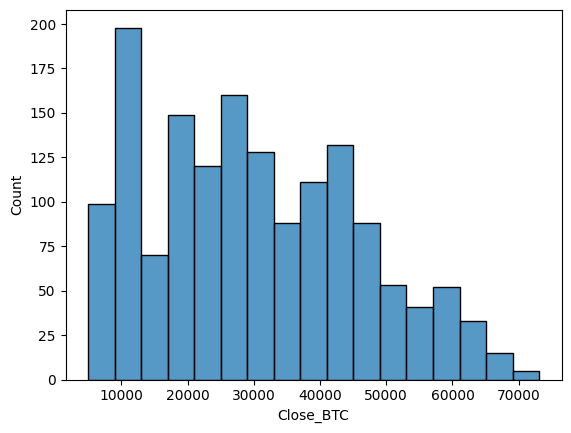

In [7]:
# Display the target feature distribution:
sns.histplot(df_combined, x=target_feature)

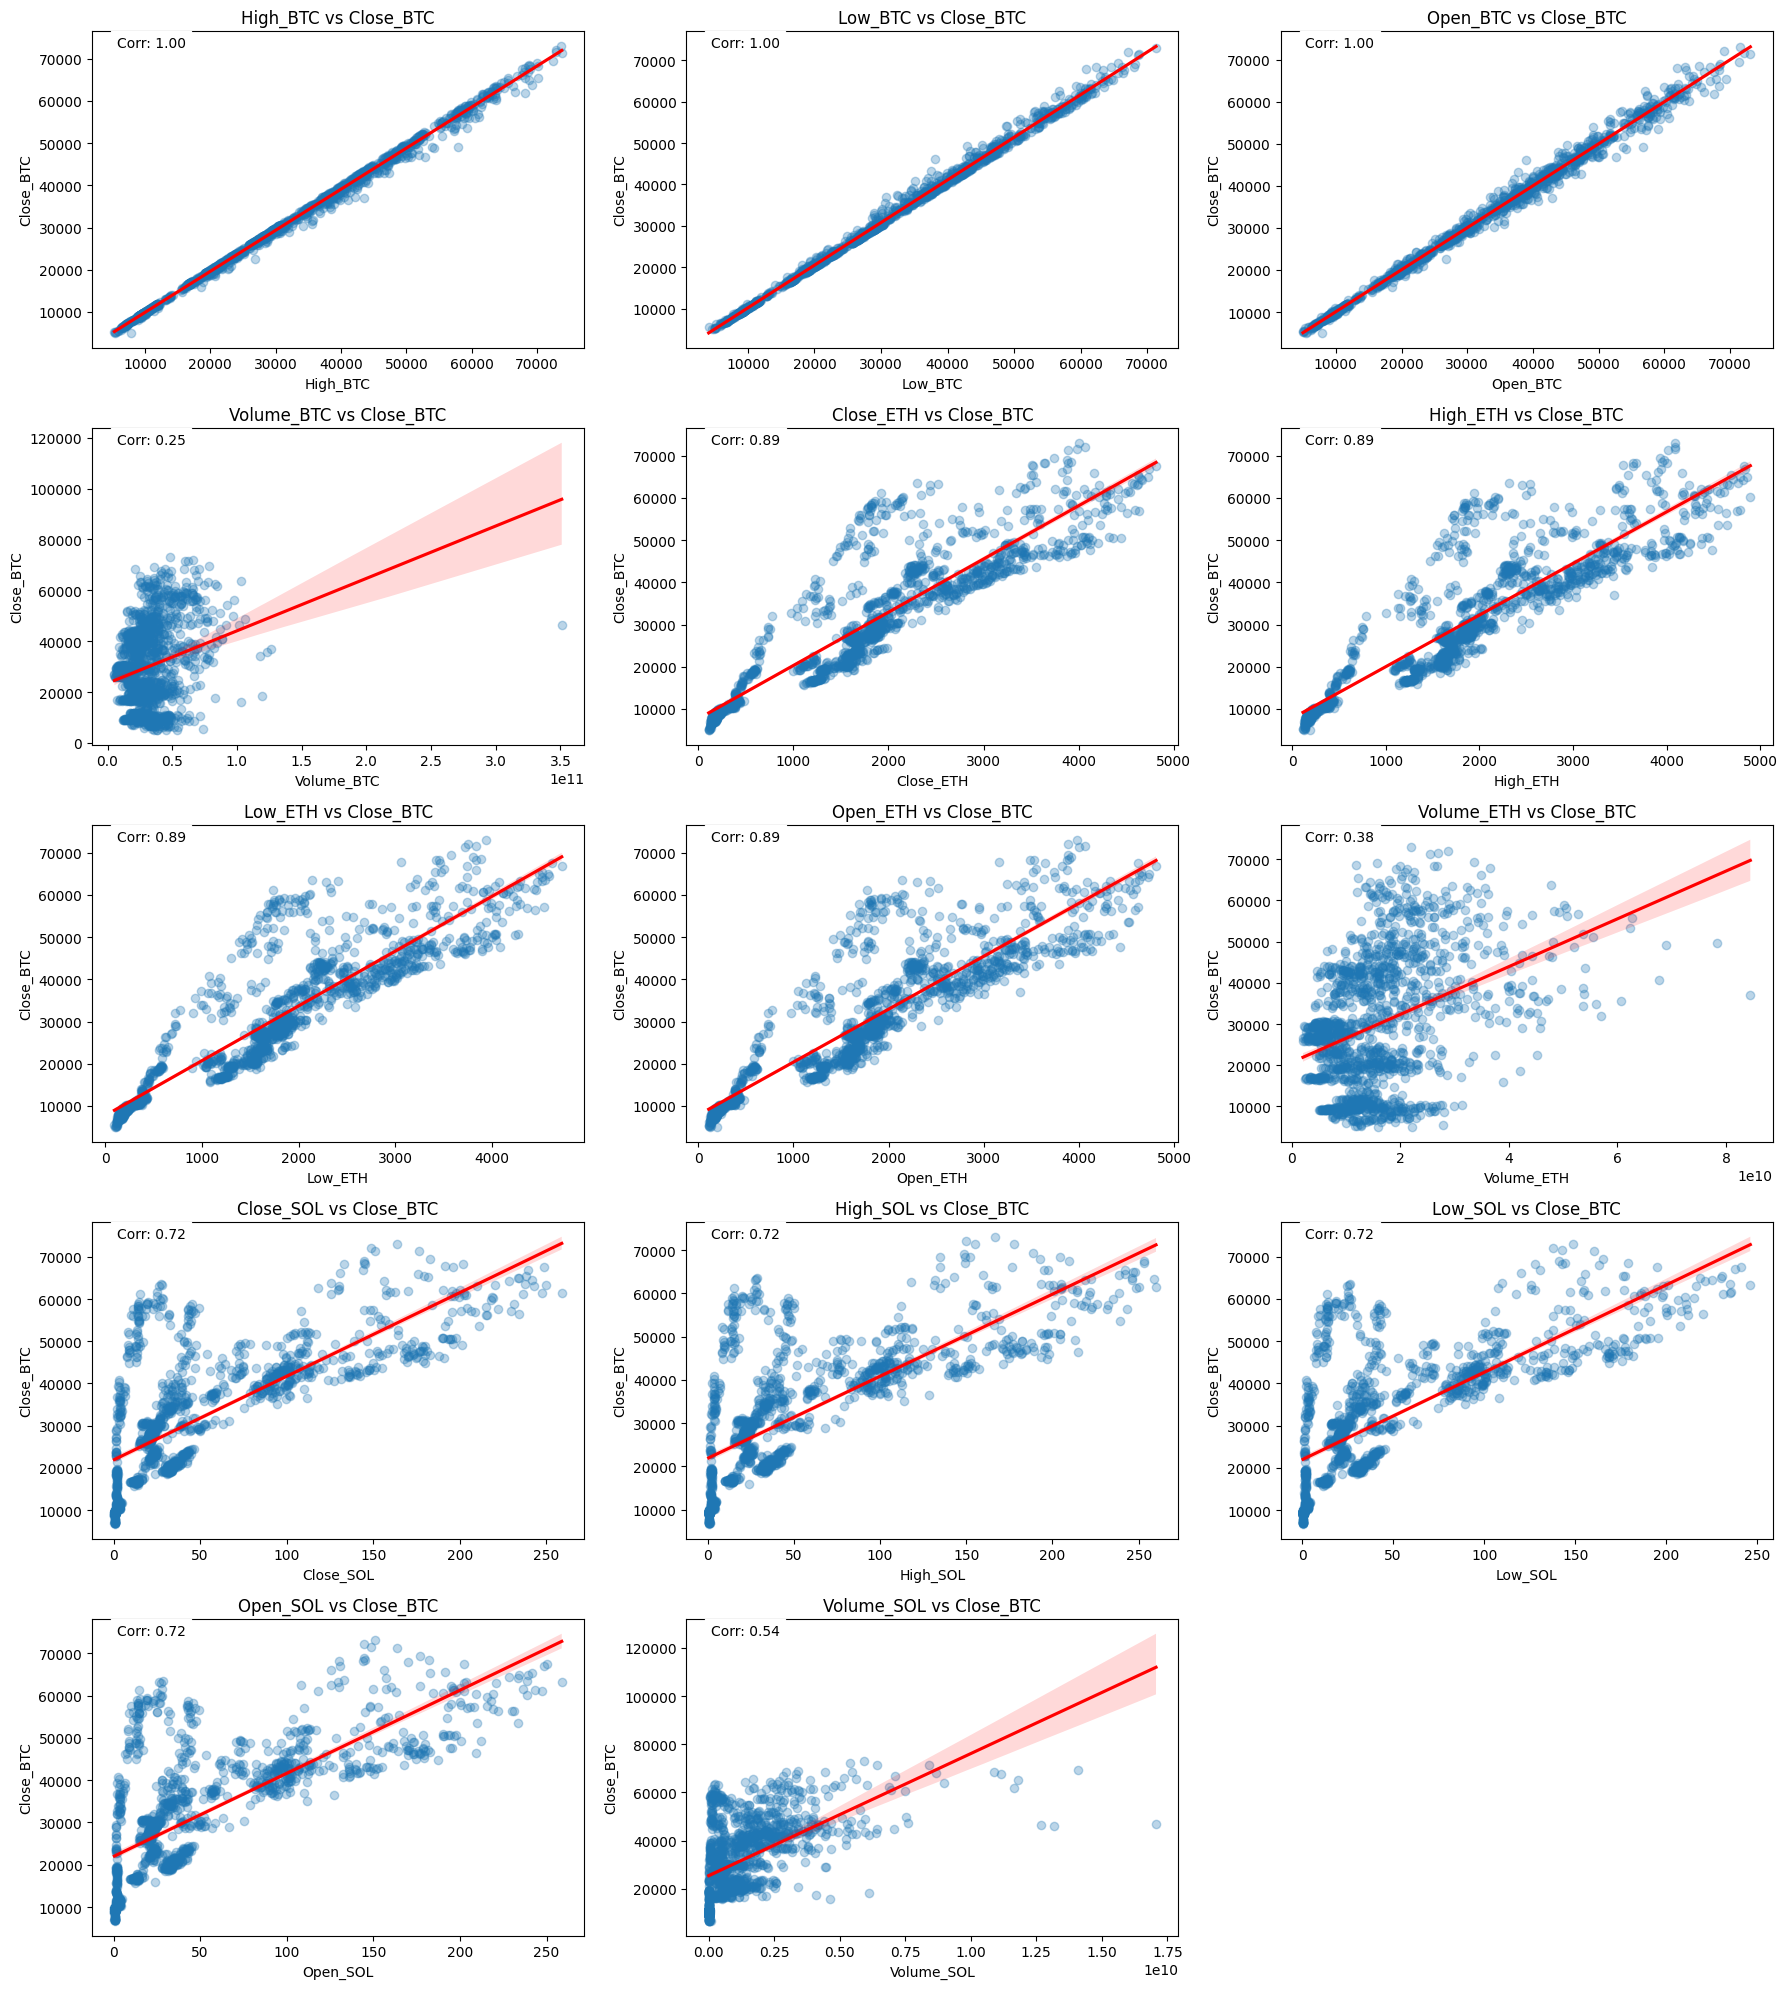

In [8]:
# Remove the target feature from the list of continuous features if it's there
if target_feature in continuous_features:
    continuous_features.remove(target_feature)

# Calculate the number of rows and columns for the subplots
n_features = len(continuous_features)
n_cols = 3 # Number of columns
n_rows = int(np.ceil(n_features / n_cols))

# Create the figure with appropriate size
plt.figure(figsize=(n_cols * 6, n_rows * 4))

# Loop through continuous features to create plots for each
for i, feature in enumerate(continuous_features, 1):
    ax = plt.subplot(n_rows, n_cols, i)
    
    sns.regplot(x=feature, y=target_feature, data=df_combined, 
                scatter_kws={'alpha': 0.3}, line_kws={'color': 'red'})
    plt.title(f'{feature} vs {target_feature}')
    
    # Add text with correlation coefficient
    corr = df_combined[[feature, target_feature]].corr().iloc[0, 1]
    plt.annotate(f'Corr: {corr:.2f}', xy=(0.05, 0.95), xycoords='axes fraction', 
                 fontsize=10, backgroundcolor='white')

plt.tight_layout()
plt.show()

<Axes: >

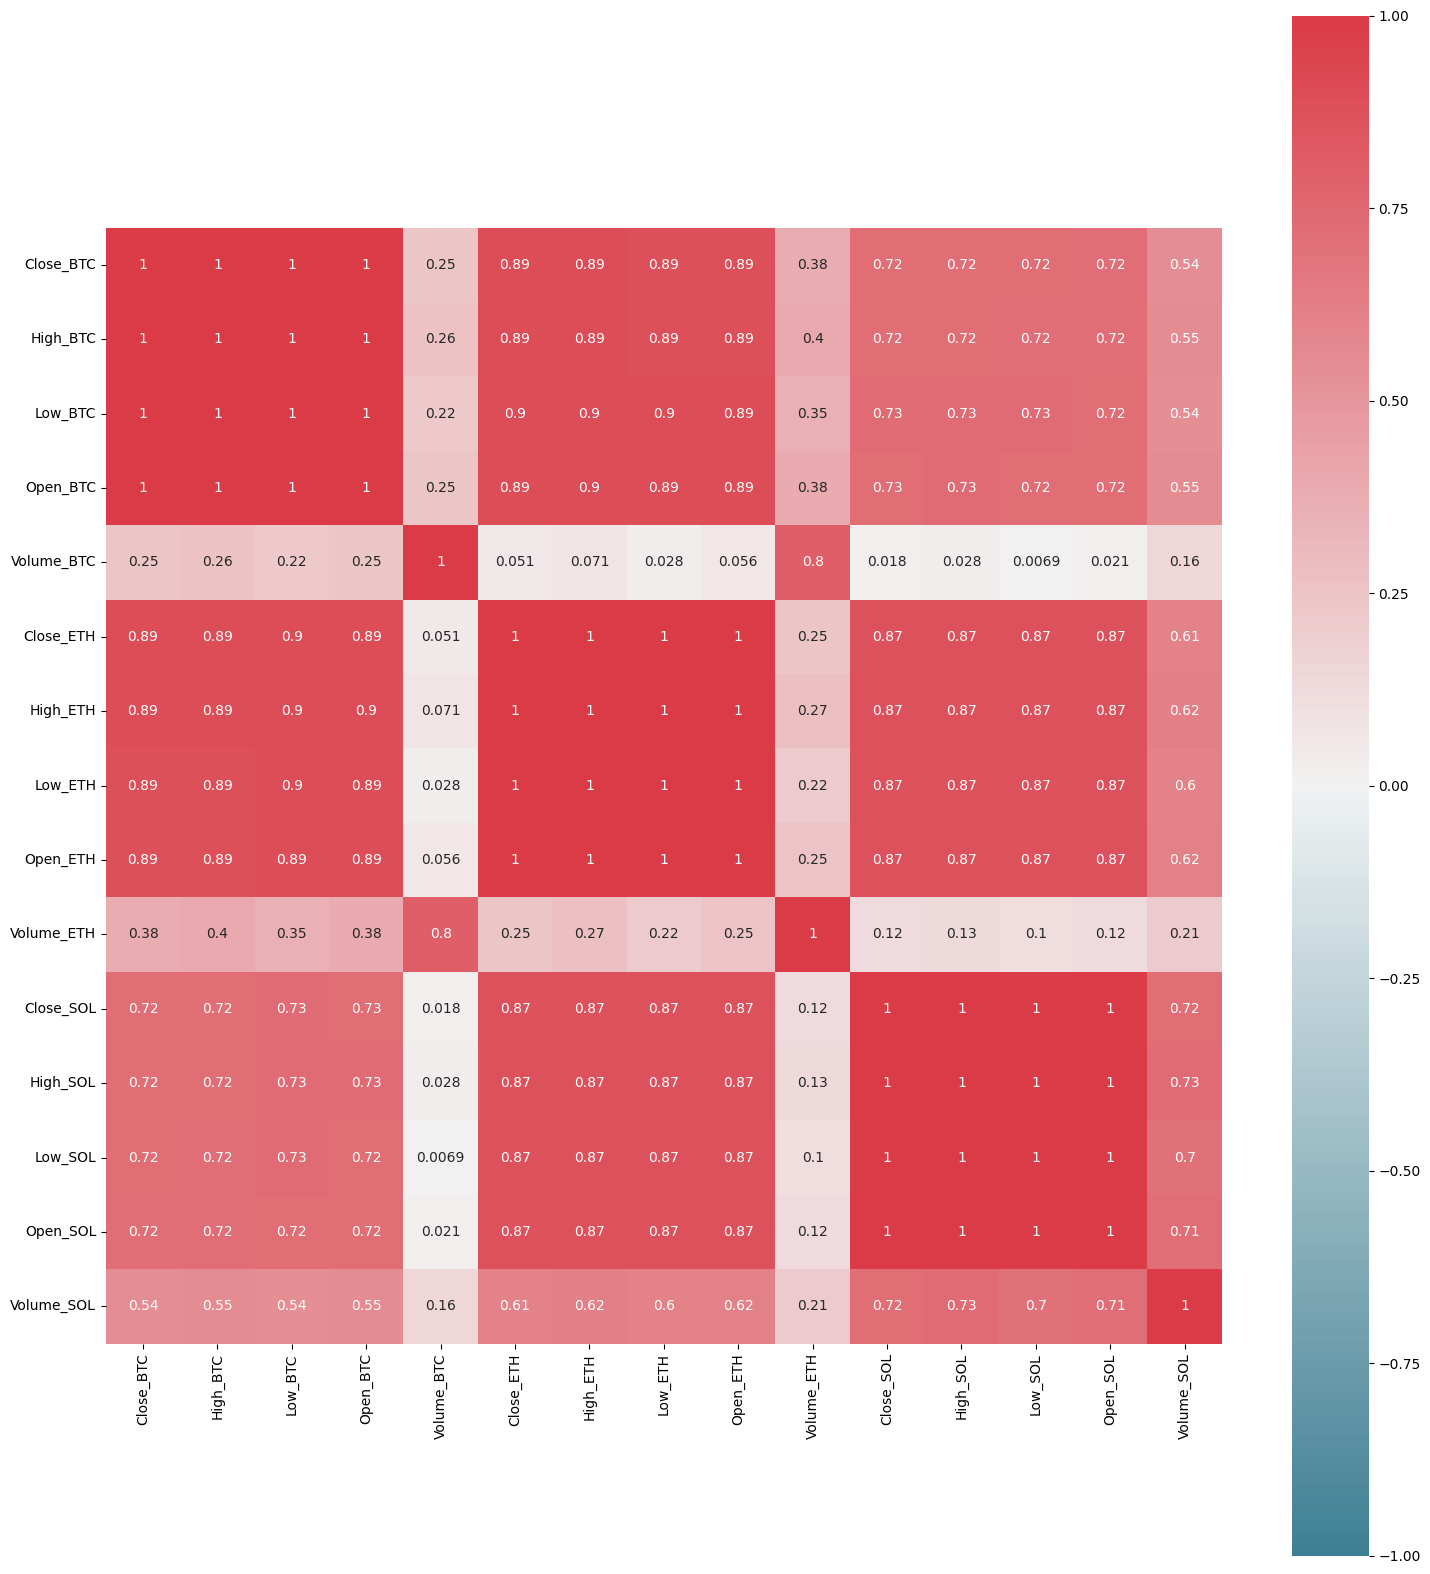

In [9]:
# Display the correlation between the continuous features:
corr = df_combined[df_combined.select_dtypes(include = ['float64', 'int64']).columns.tolist()].corr() 

# Plot the correlation matrix:
f, ax = plt.subplots(figsize=(18, 20))
sns.heatmap(corr, cmap=sns.diverging_palette(220, 10, as_cmap=True), vmin=-1.0, vmax=1.0, square=True, ax=ax, annot=True)

In [10]:
# Features with the correlation lower than 0.1:
low_corr_features = corr[(corr[target_feature] < 0.1) & (corr[target_feature] > -0.1)].index.tolist()
if len(low_corr_features) == 0:
    print('No features with correlation lower than 0.1')
else:
    print(low_corr_features)

No features with correlation lower than 0.1


Feature engineering

In [11]:
# Fill the missing values with the mean of the column:
df_combined.fillna(df_combined.mean(), inplace=True)
df_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1542 entries, 0 to 1541
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Date        1542 non-null   datetime64[ns]
 1   Close_BTC   1542 non-null   float64       
 2   High_BTC    1542 non-null   float64       
 3   Low_BTC     1542 non-null   float64       
 4   Open_BTC    1542 non-null   float64       
 5   Volume_BTC  1542 non-null   int64         
 6   Close_ETH   1542 non-null   float64       
 7   High_ETH    1542 non-null   float64       
 8   Low_ETH     1542 non-null   float64       
 9   Open_ETH    1542 non-null   float64       
 10  Volume_ETH  1542 non-null   int64         
 11  Close_SOL   1542 non-null   float64       
 12  High_SOL    1542 non-null   float64       
 13  Low_SOL     1542 non-null   float64       
 14  Open_SOL    1542 non-null   float64       
 15  Volume_SOL  1542 non-null   float64       
dtypes: datetime64[ns](1), fl

In [12]:
# Date feature split into sub-features

df_combined["year"] = df_combined["Date"].dt.year
df_combined["month"] = df_combined["Date"].dt.month
df_combined["day"] = df_combined["Date"].dt.day
df_combined["day_of_week"] = df_combined["Date"].dt.weekday  # 0 - Monday, 6 - Sunday
df_combined["week_of_year"] = df_combined["Date"].dt.isocalendar().week

df_combined["Close_lag_1"] = df_combined["Close_BTC"].shift(1)  # Price 1 day ago
df_combined["Close_lag_7"] = df_combined["Close_BTC"].shift(7)  # Price 7 days ago

# Сalculate the moving average for the last 7 days
df_combined["Close_ma_7"] = df_combined["Close_BTC"].rolling(window=7).mean()

# Drop NA values
df_combined.dropna(inplace=True)

df_combined.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1535 entries, 7 to 1541
Data columns (total 24 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          1535 non-null   datetime64[ns]
 1   Close_BTC     1535 non-null   float64       
 2   High_BTC      1535 non-null   float64       
 3   Low_BTC       1535 non-null   float64       
 4   Open_BTC      1535 non-null   float64       
 5   Volume_BTC    1535 non-null   int64         
 6   Close_ETH     1535 non-null   float64       
 7   High_ETH      1535 non-null   float64       
 8   Low_ETH       1535 non-null   float64       
 9   Open_ETH      1535 non-null   float64       
 10  Volume_ETH    1535 non-null   int64         
 11  Close_SOL     1535 non-null   float64       
 12  High_SOL      1535 non-null   float64       
 13  Low_SOL       1535 non-null   float64       
 14  Open_SOL      1535 non-null   float64       
 15  Volume_SOL    1535 non-null   float64      

In [13]:
# Last prescreen of the data
print("Data types and missing values:")
print(df_combined.head())

Data types and missing values:
         Date    Close_BTC     High_BTC      Low_BTC     Open_BTC  \
7  2020-01-08  8079.862793  8396.738281  7956.774414  8161.935547   
8  2020-01-09  7879.071289  8082.295898  7842.403809  8082.295898   
9  2020-01-10  8166.554199  8166.554199  7726.774902  7878.307617   
10 2020-01-11  8037.537598  8218.359375  8029.642090  8162.190918   
11 2020-01-12  8192.494141  8200.063477  8009.059082  8033.261719   

     Volume_BTC   Close_ETH    High_ETH     Low_ETH    Open_ETH  ...  \
7   31672559265  141.258133  146.828003  138.268204  143.487823  ...   
8   24045990466  138.979202  141.393982  136.236404  141.155777  ...   
9   28714583844  143.963776  144.167328  135.520401  138.967041  ...   
10  25521165085  142.927109  146.480911  142.207962  143.409103  ...   
11  22903438381  145.873932  146.145859  142.707642  143.032547  ...   

     Open_SOL    Volume_SOL  year  month  day  day_of_week  week_of_year  \
7   49.066451  1.204008e+09  2020      1    8

In [14]:
# Split the data into training and test sets
X = df_combined.drop(columns=[id_feature, target_feature])
y = df_combined[target_feature]

X.shape, y.shape

((1535, 22), (1535,))

***Model Implementation***

Gradient Boosted Trees

In [15]:
# Train a tree-based model:
def train_tree_model(X, y, model, params):
    """
    Train a tree-based model.

    Args:
        X (pd.DataFrame): input feature examples, size (n_examples, n_features)
        y (pd.Series): labels, size (n_examples,)
        model: a tree-based model
        params (dict): GridSearchCV's parameters
    Returns:
        model (sklearn, xgboost or lightgbm): a trained tree-based model
    """

     # Set a cross-validation strategy:
    cv_strategy = KFold(n_splits=5, shuffle=True, random_state=42)
    
    # Split the data
    X_train, X_dev, y_train, y_dev = train_test_split(X, y, test_size=0.2, random_state=0)

    # Initialize the GridSearch model
    grid_model = GridSearchCV(model, params, cv=cv_strategy, scoring="neg_root_mean_squared_error")

    # Train the GridSearch model
    grid_model.fit(X_train, y_train)

    # Get the best classifier
    model = grid_model.best_estimator_

      # Display the best estimator, score and parameters
    print("BEST ESTIMATOR:")
    print(f"{model}\n")
    print(f"Mean cross-validated score of the best estimator: {grid_model.best_score_:.3f}\n")
    print(f"Best parameters: {grid_model.best_params_}\n")

    # Obtain and display test error
    y_dev_pred = model.predict(X_dev)
    print(f"Validation RMSE: {root_mean_squared_error(y_dev, y_dev_pred):.3f}\n")

    # Display feature importance
    print("FEATURE IMPORTANCE:")

    # Analyze the TOP 30 feature importances:
    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
        feature = list(X)
        sorted_idx = np.argsort(importances)[::-1][:30]  # Indices to sort by descending importance, TOP 30 features

        # Plot TOP 30 feature importances
        plt.figure(figsize=(30, 28))
        sns.barplot(x=np.array(importances)[sorted_idx], y=np.array(feature)[sorted_idx], color="b")  # Correct indexing
        plt.title("Feature Importance")
        plt.xlabel("Importance")
        plt.ylabel("Feature")
        plt.show()
    else:
        print("Feature importance is not available for this model.")

    # Compute RMSE for different `n_estimators`
    if "n_estimators" in params:
        n_trees = params["n_estimators"]
        rmse_values = []

        for n in n_trees:
            # Train a fresh model with different `n_estimators`
            temp_model = model.set_params(n_estimators=n)
            temp_model.fit(X_train, y_train)

            # Predict on validation set
            y_dev_pred = temp_model.predict(X_dev)

            # Compute RMSE
            rmse = root_mean_squared_error(y_dev, y_dev_pred)
            rmse_values.append(rmse)

        # Plot RMSE vs. Number of Trees
        plt.figure(figsize=(10, 6))
        plt.plot(n_trees, rmse_values, marker='o', linestyle='-', color='b')
        plt.xlabel("Number of Trees")
        plt.ylabel("RMSE")
        plt.title("RMSE vs. Number of Trees")
        plt.grid(True)
        plt.show()


    return model

BEST ESTIMATOR:
XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=150,
             n_jobs=None, num_parallel_tree=None, ...)

Mean cross-validated score of the best estimator: -701.985

Best parameters: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 150}

Validation RMSE: 600.587

FEATURE IMPORTANCE:


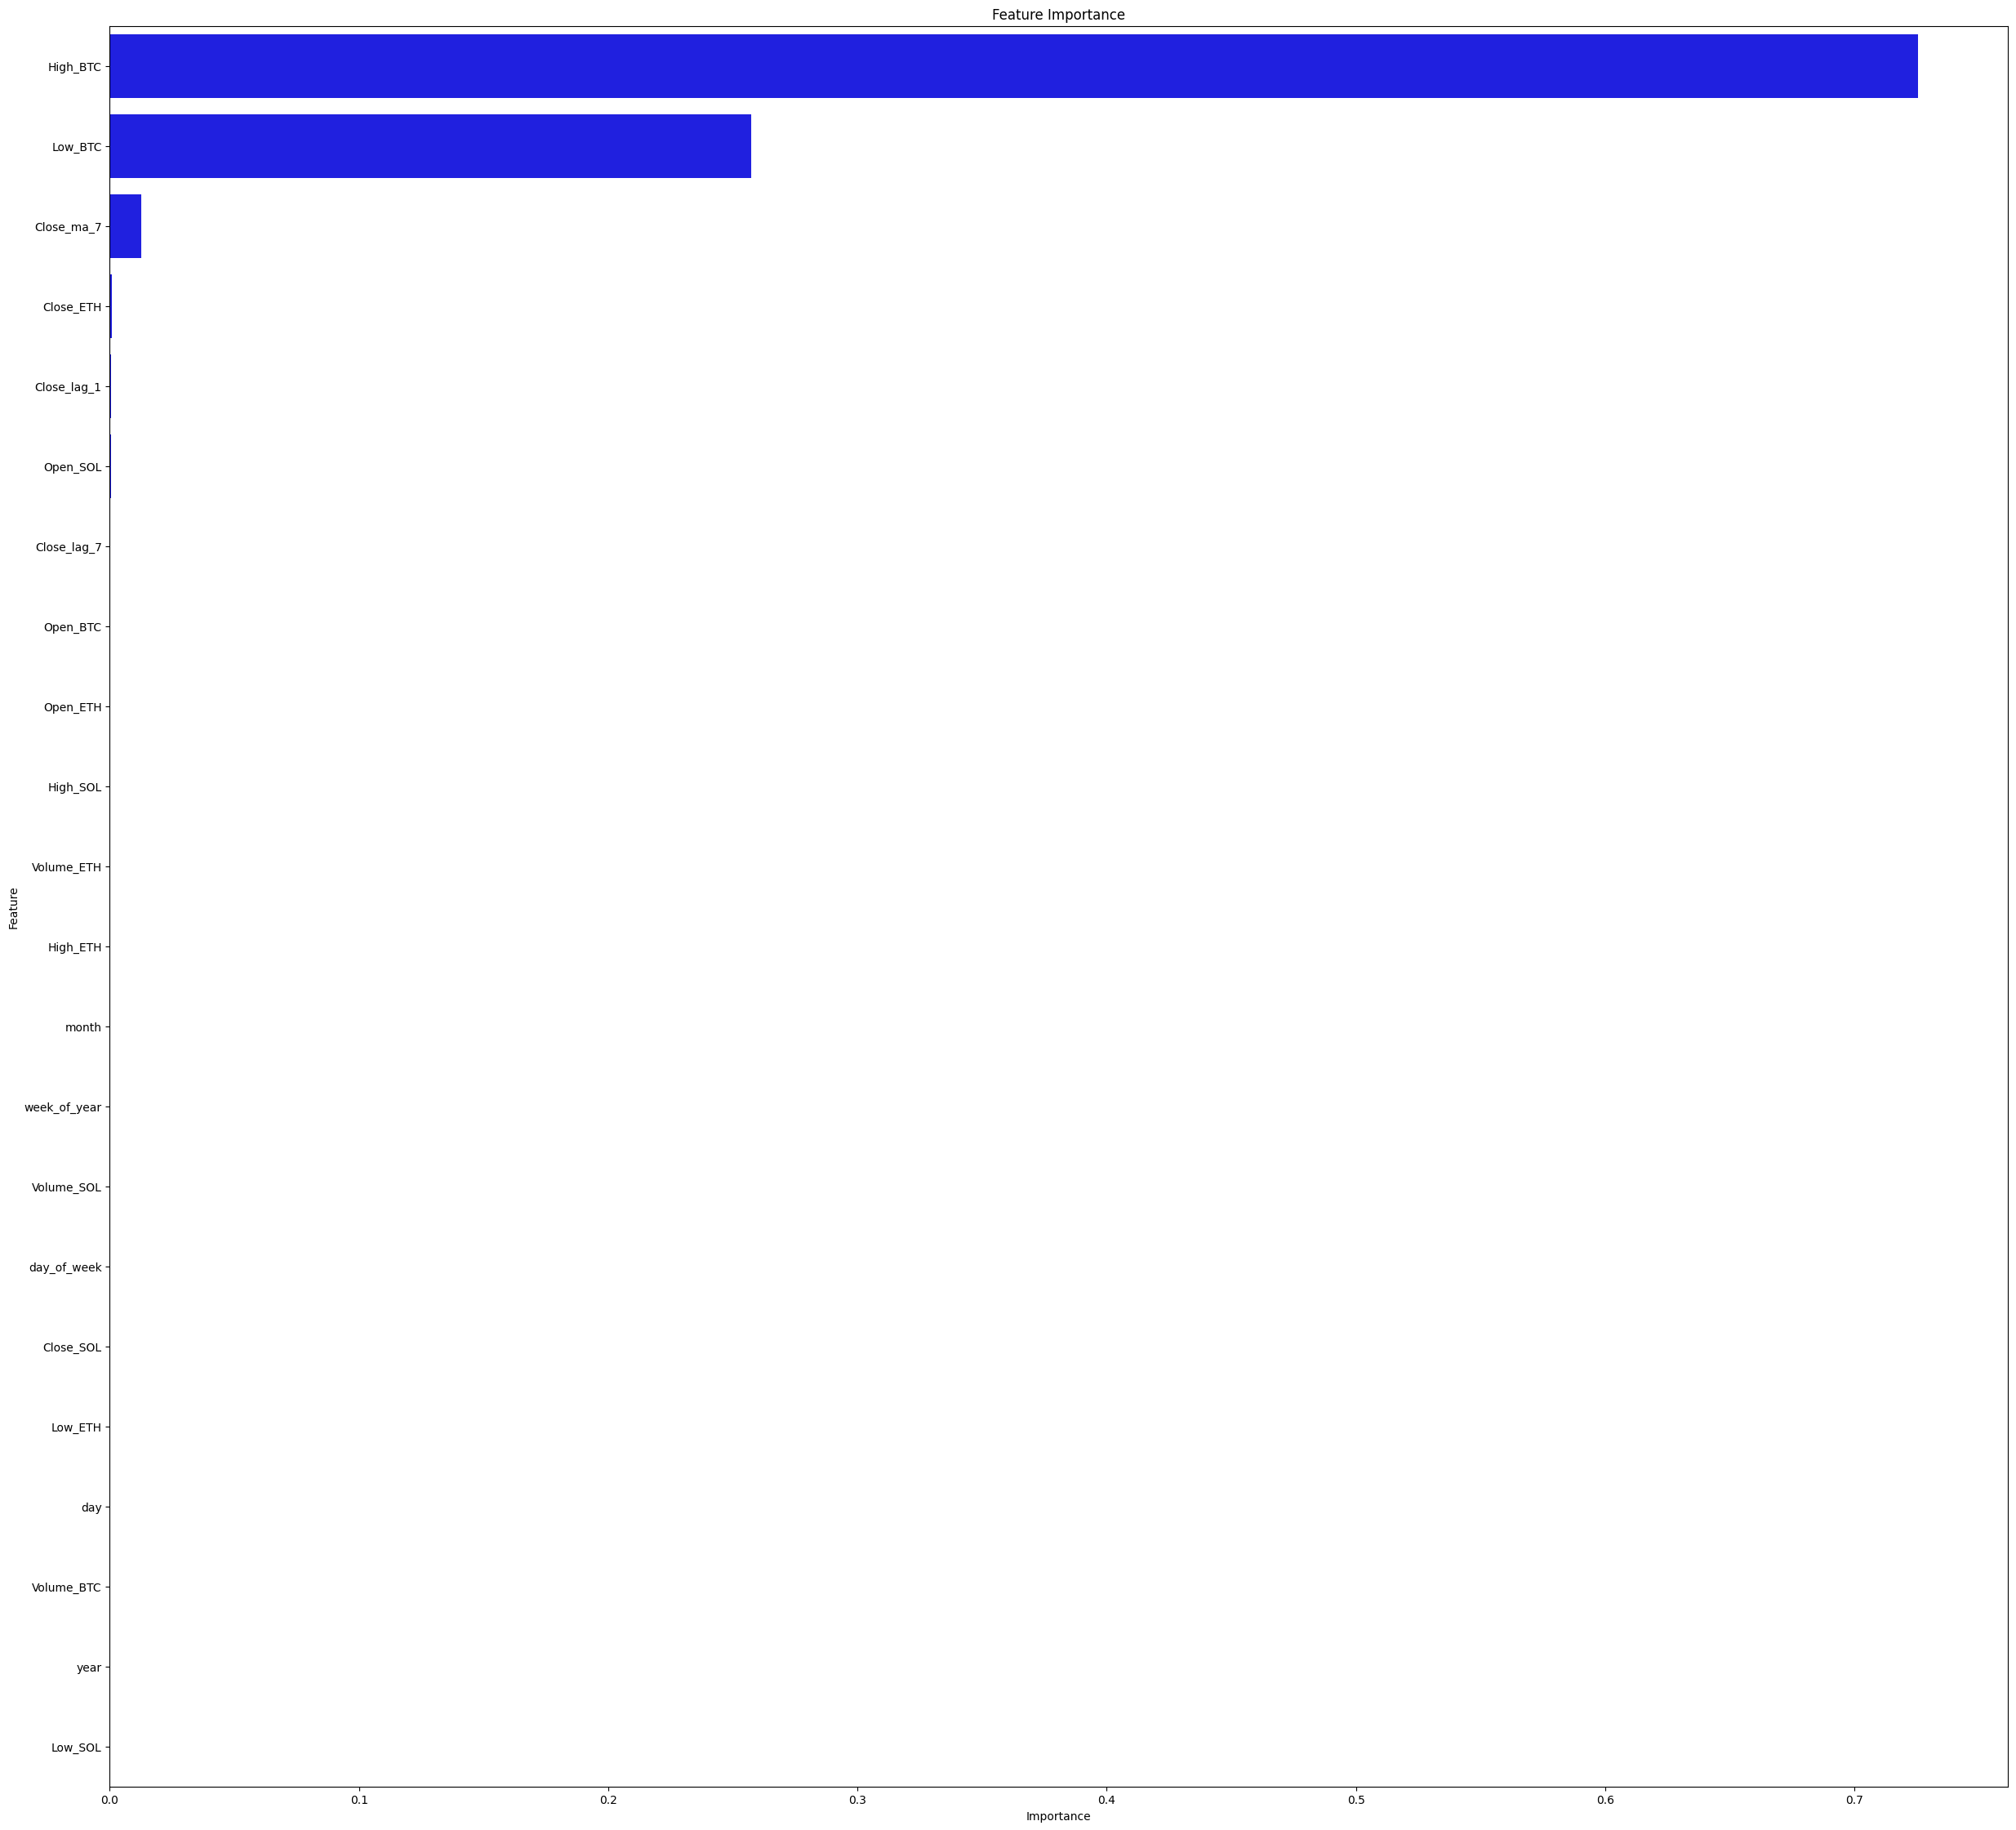

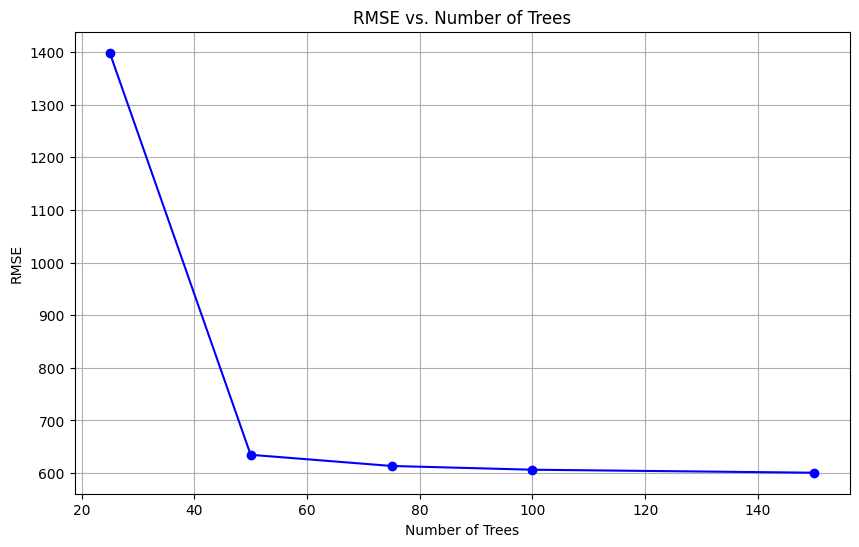

In [16]:
# Instantiate a model
xgb_model = XGBRegressor(objective='reg:squarederror', random_state=42)

# Set a parameters grid for a GridSearchCV
params = {'n_estimators': [25, 50, 75, 100, 150],
          'learning_rate': [0.1, 0.01, 0.001, 0.0001],
          'max_depth': range(3, 8)
          }

# Train the model
xgb_model_best = train_tree_model(X, y, xgb_model, params)

<Axes: >

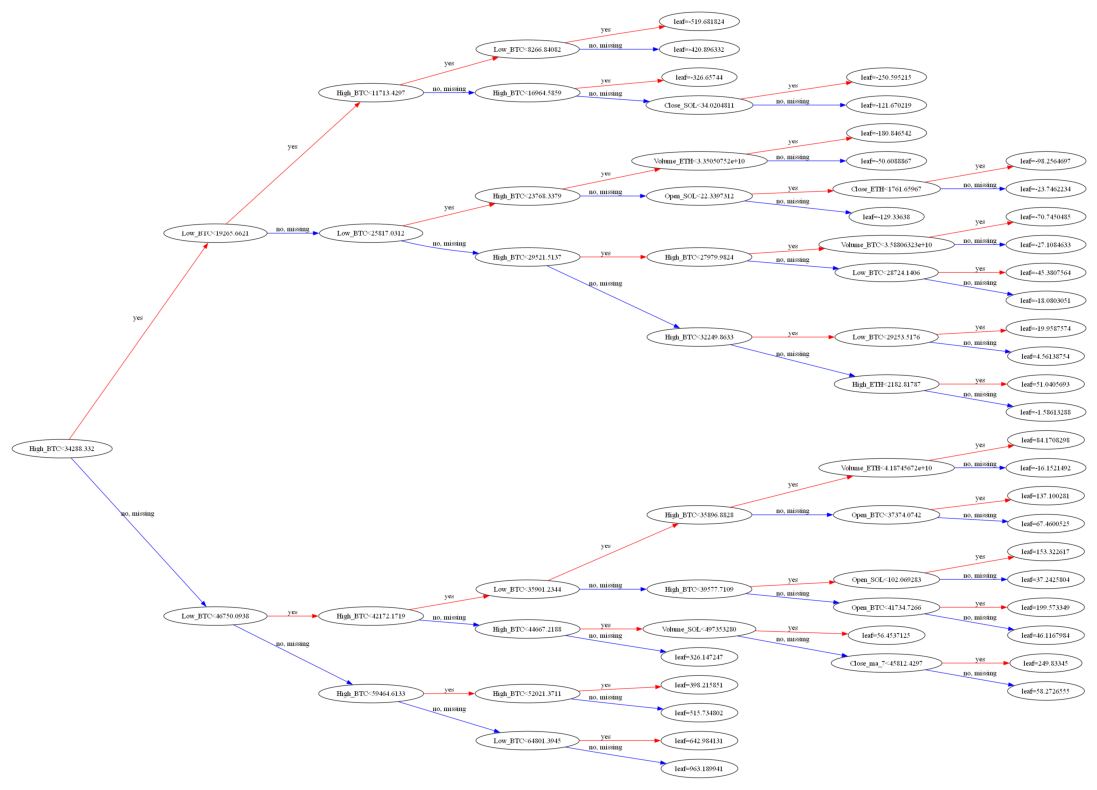

In [17]:
# Plot 15th decision tree of the XGBoost model
fig, ax = plt.subplots(figsize=(20,10))
xgb.plot_tree(xgb_model_best, tree_idx=15, rankdir='LR', ax=ax)

Try the Long Short-Term Memory Model

In [26]:
# Function to prepare the data for LSTM (convert to sequences)
def prepare_lstm_data(X, y, time_steps=60):
    X_seq, y_seq = [], []
    for i in range(time_steps, len(X)):
        X_seq.append(X[i-time_steps:i])  # Previous `time_steps` values as input
        y_seq.append(y[i])  # Target value
    return np.array(X_seq), np.array(y_seq)

# Define LSTM model training function
def train_lstm_model(X, y, model_params, time_steps=60):
    """
    Train an LSTM model.

    Args:
        X (pd.DataFrame): input feature examples, size (n_examples, n_features)
        y (pd.Series): labels, size (n_examples,)
        model_params (dict): hyperparameters for the LSTM model
        time_steps (int): the number of time steps used for each sequence

    Returns:
        model: a trained LSTM model
    """
    # Normalize the data
    scaler = MinMaxScaler(feature_range=(0, 1))
    X_scaled = scaler.fit_transform(X)
    y_scaled = scaler.fit_transform(y.values.reshape(-1, 1))

    # Prepare the data for LSTM (convert into time sequences)
    X_seq, y_seq = prepare_lstm_data(X_scaled, y_scaled, time_steps)

    # Split the data into training and validation sets
    X_train, X_val, y_train, y_val = train_test_split(X_seq, y_seq, test_size=0.2, random_state=0)

    # Build the LSTM model
    model = Sequential()
    model.add(Input(shape=(X_train.shape[1], X_train.shape[2])))  # Define input shape
    model.add(LSTM(units=model_params["units"], return_sequences=False))
    model.add(Dense(units=1))  # Predict one value
    model.compile(optimizer=model_params["optimizer"], loss='mean_squared_error')

    # Train the model
    history = model.fit(X_train, y_train, epochs=model_params["epochs"], batch_size=model_params["batch_size"], validation_data=(X_val, y_val))

    # Evaluate the model on validation data
    y_pred = model.predict(X_val)
    y_pred = scaler.inverse_transform(y_pred)
    y_val = scaler.inverse_transform(y_val)

    # Compute RMSE
    rmse = root_mean_squared_error(y_val, y_pred)
    print(f"Validation RMSE: {rmse:.3f}")

    # Plot training history
    plt.plot(history.history['loss'], label="Train Loss")
    plt.plot(history.history['val_loss'], label="Validation Loss")
    plt.legend()
    plt.title("LSTM Training History")
    plt.show()

    # Analyze the TOP 30 feature importances:
    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
        feature = list(X)
        sorted_idx = np.argsort(importances)[::-1][:30]  # Indices to sort by descending importance, TOP 30 features

        # Plot TOP 30 feature importances
        plt.figure(figsize=(30, 28))
        sns.barplot(x=np.array(importances)[sorted_idx], y=np.array(feature)[sorted_idx], color="b")  # Correct indexing
        plt.title("Feature Importance")
        plt.xlabel("Importance")
        plt.ylabel("Feature")
        plt.show()
    else:
        print("Feature importance is not available for this model.")

    return model

Epoch 1/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 10s 111ms/step - loss: 0.0578 - val_loss: 0.0048
Epoch 2/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - loss: 0.0038 - val_loss: 0.0028
Epoch 3/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - loss: 0.0023 - val_loss: 0.0023
Epoch 4/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 0.0016 - val_loss: 0.0015
Epoch 5/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - loss: 0.0013 - val_loss: 0.0012
Epoch 6/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - loss: 0.0012 - val_loss: 0.0011
Epoch 7/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 0.0012 - val_loss: 8.8406e-04
Epoch 8/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 0.0011 - val_loss: 9.1150e-04
Epoch 9/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 9.1737e-04 - val_loss: 7.9107e-04
Epoch 10/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 9.1851e-04 - val_loss: 8.2231e-04
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step
Validation RMSE: 1953.194


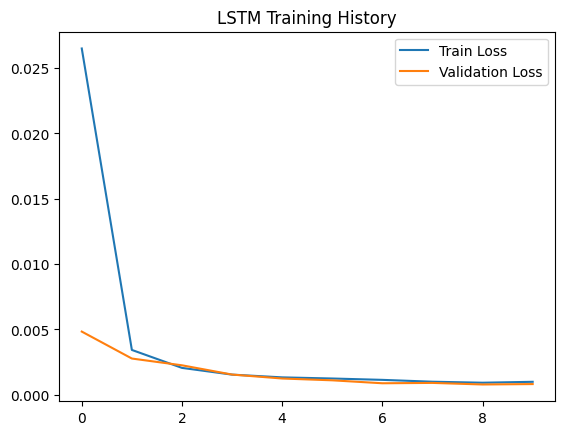

Feature importance is not available for this model.


In [27]:
model_params = {
    "units": 50,
    "optimizer": "adam",
    "epochs": 10,
    "batch_size": 32
}

model = train_lstm_model(X, y, model_params)